In [1]:
from typing import Union
import matplotlib.pyplot as plt

def parse_listing(text: str):
    '''
    Parse XML array listings which has one entry per line.
    '''
    lines = text.split('\n')
    ret: list[float] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<item>') and line.endswith('</item>')
        ret.append(float(line[6:-7].strip()))
    return ret
def parse_oplus_level_listing(text: str):
    '''
    Parse ColorOS brightness level listings which has one level per line.
    '''
    lines = text.split('\n')
    ret: list[list[float]] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<level>') and line.endswith('</level>')
        ret.append([float(t) for t in line[7:-8].strip().split(',')])
    return ret
def make_listing(values: list[Union[int, float]], indent=''):
    '''
    Create XML array listing which has one entry per line.
    '''
    ret = ''
    for value in values:
        ret += f'{indent}<item>{value}</item>\n'
    return ret

In [2]:
from typing import Sequence


def list_to_list_linear_map(val: float, src: Sequence[float], dst: Sequence[float]):
    '''
    Map the given value using the mapping defined by the two lists,
    interpolated using the linear approach.
    '''
    assert len(src) == len(dst)
    for i in range(len(src) - 1):
        assert src[i] <= src[i + 1]
    for i in range(len(src) - 1):
        if src[i] <= val <= src[i + 1]:
            break
    else:
        raise ValueError('Value out of range.')
    ratio = (val - src[i]) / (src[i + 1] - src[i])
    return dst[i] + (dst[i + 1] - dst[i]) * ratio

## Source data

Below is brightness metrics from ColorOS port (nits values seems mostly accurate, no auto brightness info),
LineageOS (seems not quite correct, and auto brightness is known to be problematic)
and crDroid (nits value not quite correct, auto brightness mostly works).

Terms:

- nits: The physical brightness value, used as a standard intermediary metric for communicating brightness.
- backlight: Legacy backlight value. Can describe non-HBM brightness levels only. Valid range from 1 to 255.
- register: The value stored in `/sys/class/backlight/panel0-backlight/brightness`.
  For our panel, the sustainable non-HBM range is from 1 to 2047 (0 is completely black),
  and the HBM (High Brightness Mode) range is from 2048 to 4095.

In [3]:
oos_brightness_profile = parse_oplus_level_listing(open('./cos_brightness_profile.txt', 'r').read())
los_backlight = parse_listing('''
    <item>0</item>
    <item>4</item>
    <item>8</item>
    <item>12</item>
    <item>16</item>
    <item>20</item>
    <item>24</item>
    <item>28</item>
    <item>32</item>
    <item>36</item>
    <item>40</item>
    <item>44</item>
    <item>48</item>
    <item>52</item>
    <item>56</item>
    <item>60</item>
    <item>64</item>
    <item>68</item>
    <item>72</item>
    <item>76</item>
    <item>80</item>
    <item>84</item>
    <item>88</item>
    <item>92</item>
    <item>96</item>
    <item>100</item>
    <item>104</item>
    <item>108</item>
    <item>112</item>
    <item>116</item>
    <item>120</item>
    <item>123</item>
    <item>127</item>
    <item>131</item>
    <item>135</item>
    <item>139</item>
    <item>143</item>
    <item>147</item>
    <item>151</item>
    <item>155</item>
    <item>159</item>
    <item>163</item>
    <item>167</item>
    <item>171</item>
    <item>175</item>
    <item>179</item>
    <item>183</item>
    <item>187</item>
    <item>191</item>
    <item>195</item>
    <item>199</item>
    <item>203</item>
    <item>207</item>
    <item>211</item>
    <item>215</item>
    <item>219</item>
    <item>223</item>
    <item>227</item>
    <item>231</item>
    <item>235</item>
    <item>239</item>
    <item>243</item>
    <item>246</item>
    <item>251</item>
    <item>255</item>
''')
los_nits = parse_listing('''
    <item>0.0</item>
    <item>2.1</item>
    <item>2.31</item>
    <item>2.63</item>
    <item>3.16</item>
    <item>3.73</item>
    <item>4.42</item>
    <item>5.45</item>
    <item>6.69</item>
    <item>8.07</item>
    <item>9.65</item>
    <item>11.32</item>
    <item>13.26</item>
    <item>15.59</item>
    <item>18.14</item>
    <item>20.68</item>
    <item>23.58</item>
    <item>26.38</item>
    <item>29.67</item>
    <item>32.83</item>
    <item>36.03</item>
    <item>39.31</item>
    <item>43.8</item>
    <item>47.95</item>
    <item>52.08</item>
    <item>56.86</item>
    <item>61.83</item>
    <item>67.93</item>
    <item>73.37</item>
    <item>79.96</item>
    <item>86.15</item>
    <item>90.75</item>
    <item>97.83</item>
    <item>105.67</item>
    <item>112.79</item>
    <item>120.33</item>
    <item>127.82</item>
    <item>135.71</item>
    <item>145.0</item>
    <item>153.32</item>
    <item>161.78</item>
    <item>170.61</item>
    <item>179.7</item>
    <item>190.25</item>
    <item>201.81</item>
    <item>212.07</item>
    <item>222.79</item>
    <item>234.01</item>
    <item>246.43</item>
    <item>257.49</item>
    <item>269.8</item>
    <item>281.41</item>
    <item>293.94</item>
    <item>307.58</item>
    <item>322.53</item>
    <item>335.82</item>
    <item>349.68</item>
    <item>364.86</item>
    <item>379.57</item>
    <item>398.55</item>
    <item>413.85</item>
    <item>429.97</item>
    <item>442.89</item>
    <item>461.76</item>
    <item>478.65</item>
''')
los_auto_lux = parse_listing('''
    <item>1</item>
    <item>4</item>
    <item>12</item>
    <item>20</item>
    <item>28</item>
    <item>47</item>
    <item>63</item>
    <item>86</item>
    <item>150</item>
    <item>160</item>
    <item>220</item>
    <item>270</item>
    <item>360</item>
    <item>420</item>
    <item>510</item>
    <item>620</item>
    <item>1000</item>
    <item>2000</item>
    <item>3100</item>
    <item>5000</item>
    <item>8000</item>
    <item>12000</item>
    <item>16000</item>
    <item>20000</item>
''')
los_auto_nits = parse_listing('''
    <item>2.0487</item>
    <item>4.8394</item>
    <item>15.2619</item>
    <item>30.2619</item>
    <item>46.671</item>
    <item>65.95</item>
    <item>80.46</item>
    <item>84.38</item>
    <item>89.51</item>
    <item>100.34</item>
    <item>102.21</item>
    <item>109.48</item>
    <item>114.19</item>
    <item>123.86</item>
    <item>129.18</item>
    <item>138.07</item>
    <item>145.62</item>
    <item>168.84</item>
    <item>234.9</item>
    <item>280</item>
    <item>320</item>
    <item>360</item>
    <item>405</item>
    <item>450</item>
    <item>500</item>
''')
crd_backlight = parse_listing('''
    <item>1</item>
    <item>255</item>
''')
crd_nits = parse_listing('''
    <item>1</item>
    <item>1100</item>
''')
crd_auto_lux = parse_listing('''
    <item>1</item>
    <item>4</item>
    <item>12</item>
    <item>20</item>
    <item>28</item>
    <item>47</item>
    <item>63</item>
    <item>86</item>
    <item>150</item>
    <item>220</item>
    <item>270</item>
    <item>360</item>
    <item>420</item>
    <item>510</item>
    <item>620</item>
    <item>1000</item>
    <item>2000</item>
    <item>3100</item>
    <item>3988</item>
    <item>5018</item>
    <item>6232</item>
    <item>7648</item>
    <item>9280</item>
    <item>11146</item>
    <item>13261</item>
    <item>15640</item>
    <item>18302</item>
    <item>21260</item>
    <item>24532</item>
    <item>28133</item>
    <item>32080</item>
    <item>36388</item>
    <item>41073</item>
    <item>46153</item>
    <item>51642</item>
    <item>63912</item>
    <item>78015</item>
    <item>94076</item>
    <item>112226</item>
    <item>132592</item>
    <item>155302</item>
    <item>180486</item>
    <item>208271</item>
    <item>223180</item>
    <item>255108</item>
''')
crd_auto_nits = parse_listing('''
    <item>2.0487</item>
    <item>4.8394</item>
    <item>15.2619</item>
    <item>33</item>
    <item>49</item>
    <item>62.95</item>
    <item>76.46</item>
    <item>84.38</item>
    <item>89.51</item>
    <item>100.34</item>
    <item>109.48</item>
    <item>115</item>
    <item>117.67</item>
    <item>122.72</item>
    <item>131.17</item>
    <item>141.19</item>
    <item>167.05</item>
    <item>234.9</item>
    <item>279</item>
    <item>300</item>
    <item>320</item>
    <item>340</item>
    <item>360</item>
    <item>380</item>
    <item>400</item>
    <item>420</item>
    <item>440</item>
    <item>460</item>
    <item>480</item>
    <item>500</item>
    <item>520</item>
    <item>540</item>
    <item>560</item>
    <item>580</item>
    <item>600</item>
    <item>620</item>
    <item>660</item>
    <item>700</item>
    <item>740</item>
    <item>780</item>
    <item>820</item>
    <item>860</item>
    <item>900</item>
    <item>940</item>
    <item>1000</item>
    <item>1100</item>
''')
oos_register_hbm_max = 4095
oos_register_sustainable_max = 2047
oos_register = [ item[1] for item in oos_brightness_profile ]
oos_nits = [ item[2] for item in oos_brightness_profile ]
los_auto_lux = [0, *los_auto_lux]
crd_auto_lux = [0, *crd_auto_lux]


## Explore ColorOS brightness profile

First let's plot and observe the ColorOS brightness profile, which seems mostly accurate.

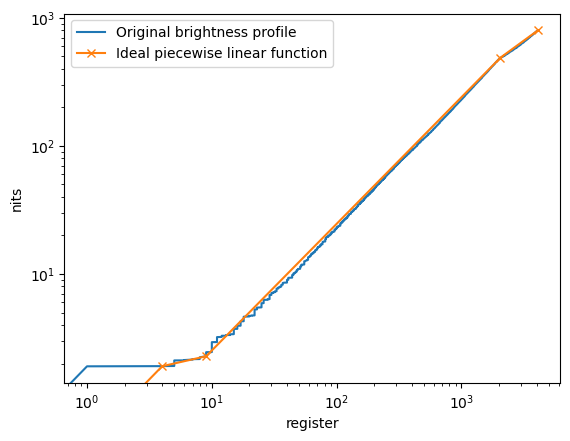

In [4]:
plt.plot(oos_register, oos_nits, label='Original brightness profile')
oos_register_key_points = [0, 4, 9, 2047, 4095]
oos_nits_key_points = [ list_to_list_linear_map(item, oos_register, oos_nits) for item in oos_register_key_points ]
plt.plot(
    oos_register_key_points,
    oos_nits_key_points,
    marker='x',
    label='Ideal piecewise linear function'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('register')
plt.ylabel('nits')
plt.legend()

Conclusion: The register to nits mapping is mostly piecewise linear. The key points are:
- register=0: Completely black.
- register=4: The minimum brightness formerly set in LineageOS.
  As we have tested, register=3 appear darker
  but indeed unusable since the color accuracy is significantly bad (shifts to red).
- register=9: The minimum brightness set in stock ColorOS/OxygenOS 14 and crDroid (OnePlus 8T).
- register=2047: Sustainable maximum.
- register=4095: HBM maximum.

## Create a reasonable auto brightness mapping

First let's plot the former LineageOS and crDroid (OnePlus 8T) and compare them.
Since crDroid's brightness profile defines the sustainable maximum to be 1100nits (obviously incorrect),
we normalize to make the maximum nits of the auto brightness curve match the one of LineageOS.

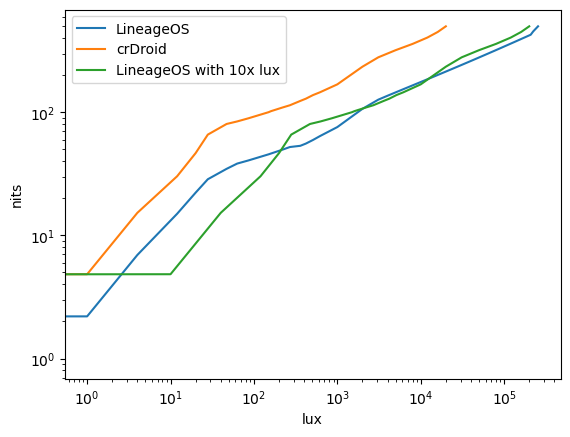

In [5]:
crd_auto_nits_max = max(*crd_auto_nits)
los_auto_nits_max = max(*los_auto_nits)
plt.plot(crd_auto_lux, [item / crd_auto_nits_max * los_auto_nits_max for item in crd_auto_nits], label='LineageOS')
plt.plot([item for item in los_auto_lux], los_auto_nits, label='crDroid')
plt.plot([item * 10 for item in los_auto_lux], los_auto_nits, label='LineageOS with 10x lux')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('lux')
plt.ylabel('nits')
plt.legend()

This aligns with our observation that LineageOS' auto brightness is constantly significantly too bright
while crDroid's auto brightness mostly works.

However, by comparing the lux readings from LineageOS and stock differs wildly (the former is way higher).
It seems that a resonable behavior (reasonable values, no discontinuity)
can be achieved by changing the kernel device tree sensor config
(`/kernel/oneplus/sm8250/arch/arm64/boot/dts/vendor/oplus/lemonades/kona-sensor.dtsi`).
Such config makes use of an undocumented behavior of the sensor when `als-type` is set to 0, since all other
settings fail to produce such reasonable behavior.

Then, according to LineageOS and crDroid curves and real experiments, we make an idfeal curve
function and use it as our auto brightness curve.

Finally, it can be found by experiment that the maximum extra reading (after changing the kernel config)
contributed by "reflection" when the screen is displaying white under max sustainable brightness 
and moderate ambient light is approximately 30 lux.
We must prevent our suto brightness lux-nits curve from intersecting with the self-reflex lux-nits line,
since this can completely prevent the screen brightness from going down to zero even in an ideal dark room.
Ideally the self-reflex lux-nits line should be far above our curve to make auto brightness adequately consistent
between bright and dark mode UI.
Hence we do the `p_sum` between our ideal function and the self-reflex curve in some settings to enforce that.

Ideal curve max: (50000, 796.744414965529)


/tmp/ipykernel_46298/178332788.py:95: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, max_hbm_nits)


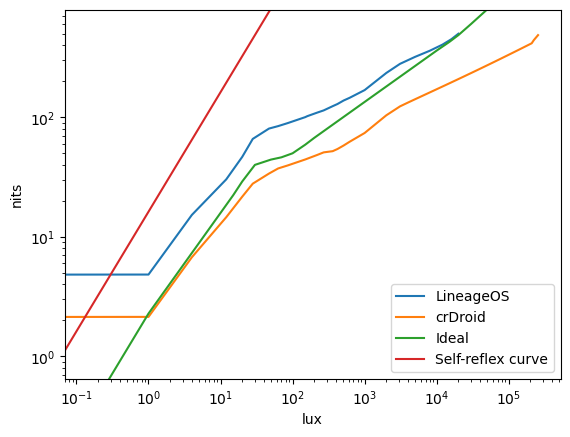

In [6]:
from math import exp, isclose, log
from typing import Sequence, Tuple
import math

max_sustainable_nits = list_to_list_linear_map(oos_register_sustainable_max, oos_register_key_points, oos_nits_key_points)
max_hbm_nits = list_to_list_linear_map(oos_register_hbm_max, oos_register_key_points, oos_nits_key_points)
crd_corrected_auto_nits = [item / 1100 * max_sustainable_nits for item in crd_auto_nits]

max_sustainable_reflex_lux = 30

def p_sum(a, b, p):
    if isclose(a, 0) or isclose(b, 0):
        return min(a, b)
    return ((a ** p + b ** p)) ** (1/p)
def log_splend(item: float, ease_sigma: float, *points: Tuple[float, float]):
    assert len(points) >= 2
    l_points = [ (math.log10(point[0]), math.log10(point[1])) for point in points ]
    l_lines = []
    weights = []
    l_item = math.log10(item)
    for i in range(len(l_points) - 1):
        p1 = l_points[i]
        p2 = l_points[i+1]
        slope = (p2[1] - p1[1]) / (p2[0] - p1[0])
        l_lines.append((slope, p2[1] - p2[0] * slope))
        if p1[0] <= l_item <= p2[0]:
            weights.append(1)
        else:
            weights.append(exp(-max(p1[0]-l_item, l_item-p2[0])** 2 / 2 / ease_sigma**2))
    y = sum([ (l_lines[i][0] * l_item + l_lines[i][1]) * weights[i] for i in range(len(l_lines)) ]) / sum(weights)
    return 10 ** y

plt.plot(los_auto_lux, los_auto_nits, label='LineageOS')
plt.plot(crd_auto_lux, crd_corrected_auto_nits, label='crDroid')

def make_ideal_lux_nits(lux_to_nit_func):
    from_lux_vals = sum([ [ 1*10**t, 1.5*10**t, 2*10**t, 3*10**t, 5*10**t, 7*10**t ] for t in range(0, 10) ], start=[])
    lux_vals = [ 0 ]
    nits_vals = [ 0.0 ]
    for item in from_lux_vals:
        if not math.isclose(round(item), item):
            continue
        nit = lux_to_nit_func(item)
        lux_vals.append(int(item))
        nits_vals.append(float(nit))
        if nit >= max_hbm_nits * (1 - 1e-2):
            break
    return lux_vals, nits_vals

def curve_topoff(xs, ys, max_y, keep_tail = False):
    ret_xs = []
    ret_ys = []
    assert len(xs) == len(ys)
    reached_tail = False
    for i in range(len(xs)):
        if i > 0 and ys[i] > max_y:
            if ys[i - 1] < max_y * (1 - 5e-3):
                approx_y = max_y
                approx_x = list_to_list_linear_map(max_y, ys, xs)
                ret_xs.append(approx_x)
                ret_ys.append(approx_y)
            if keep_tail:
                reached_tail = True
            else:
                break
        ret_xs.append(xs[i])
        ret_ys.append(max_y if reached_tail else ys[i])
    return ret_xs, ret_ys

# 2 (2026-07-29)
ideal_auto_lux, ideal_auto_nits = make_ideal_lux_nits(lambda item:
    # p_sum(
        log_splend(
            item,
            0.08,
            (1, list_to_list_linear_map(9, oos_register_key_points, oos_nits_key_points)),
            (30, 40),
            (100, 50),
            (20000, max_sustainable_nits),
            (50000, max_hbm_nits),
        )
    #     , item * 0.5 / max_sustainable_reflex_lux * max_sustainable_nits,
    #     -1
    # )
)
plt.plot(ideal_auto_lux, ideal_auto_nits, label='Ideal')
print(f'Ideal curve max: ({max(*ideal_auto_lux)}, {max(*ideal_auto_nits)})')

auto_lux = ideal_auto_lux
auto_nits = ideal_auto_nits
plt.xscale('log')
plt.yscale('log')
plt.xlabel('lux')
plt.ylabel('nits')
plt.ylim(0, max_hbm_nits)

auto_reflex_white_lux = [item / max_sustainable_nits * max_sustainable_reflex_lux for item in auto_nits]
auto_reflex_black_lux = [0.0 for item in auto_nits]
plt.plot(auto_reflex_white_lux, auto_nits, label='Self-reflex curve')
plt.legend()

Examples of simulating auto brightness change, for all-white and all-back screen content respectively.

(1500.0, 159.9999309066236)
(204.0, 67.84228914278174)
(21.92065390961049, 31.15768732636469)
(5.599049085861691, 9.718120304266362)
(5.0, 8.850073207884558)
(2.0, 4.091923596359482)
(1.0, 2.2829435000000005)


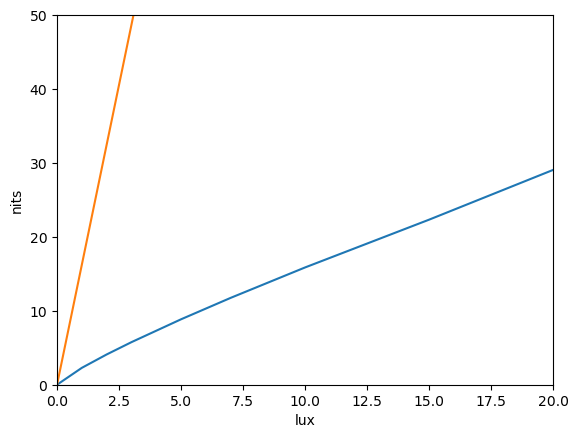

In [7]:
def simulate_brightness_change(
    env_lux: float,
    start_nits: float,
    auto_lux: list[float],
    auto_nits: list[float],
    auto_reflex_lux: list[float],
    /,
    step_lim: tuple[float, float] = (0.95, 1.05),
    lux_change_thresh: tuple[float, float] = (1, 1)
):
    eps = 1e-2
    curr_nits = start_nits
    min_nits, max_nits = min(*auto_nits), max(*auto_nits)
    min_lux, max_lux = min(*auto_lux), max(*auto_lux)
    while True:
        prev_nits = curr_nits
        reflex_lux = list_to_list_linear_map(
            curr_nits,
            auto_nits, auto_reflex_lux
        )
        should_lux = list_to_list_linear_map(
            curr_nits,
            auto_nits, auto_lux
        )
        curr_lux = reflex_lux + env_lux
        if lux_change_thresh[0] * should_lux <= curr_lux <= lux_change_thresh[1] * should_lux:
            break
        curr_nits = list_to_list_linear_map(
            max(min_lux, min(max_lux, curr_lux)),
            auto_lux, auto_nits,
        )
        curr_nits = max(step_lim[0] * prev_nits, min(step_lim[1] * prev_nits, curr_nits))
        curr_nits = max(min_nits, min(max_nits, curr_nits))
        if abs(curr_nits - prev_nits) < eps:
            break
    return curr_lux, curr_nits

plt.plot(auto_lux, auto_nits)
plt.plot(auto_reflex_white_lux, auto_nits)
plt.xlim(0, 20)
plt.ylim(0, 50)
plt.xlabel('lux')
plt.ylabel('nits')
print(simulate_brightness_change(1500, 150, auto_lux, auto_nits, auto_reflex_black_lux))
print(simulate_brightness_change(204, 150, auto_lux, auto_nits, auto_reflex_black_lux))
print(simulate_brightness_change(20, 150, auto_lux, auto_nits, auto_reflex_white_lux))
print(simulate_brightness_change(5, 150, auto_lux, auto_nits, auto_reflex_white_lux))
print(simulate_brightness_change(5, 150, auto_lux, auto_nits, auto_reflex_black_lux))
print(simulate_brightness_change(2, 150, auto_lux, auto_nits, auto_reflex_black_lux))
print(simulate_brightness_change(1, 150, auto_lux, auto_nits, auto_reflex_black_lux))

## Final Answers

### Panel-specific displayconfig

For `config/display/display_id_xxxx.xml`.

#### Screen brightness map

In [8]:
text = ''
text += '    <screenBrightnessMap interpolation="linear">\n'
for i in range(len(oos_register_key_points)):
    level = oos_register_key_points[i]
    nit = oos_nits_key_points[i]
    text += f'        <point><value>{level / oos_register_hbm_max}</value><nits>{nit}</nits></point>\n'
text += '    </screenBrightnessMap>\n'
print(text)

    <screenBrightnessMap interpolation="linear">
        <point><value>0.0</value><nits>0.0</nits></point>
        <point><value>0.0009768009768009768</value><nits>1.9087942</nits></point>
        <point><value>0.002197802197802198</value><nits>2.2829435</nits></point>
        <point><value>0.4998778998778999</value><nits>486.74194</nits></point>
        <point><value>1.0</value><nits>796.74475</nits></point>
    </screenBrightnessMap>



#### Global HBM parameters

In [9]:
print('Transition point:', oos_register_sustainable_max / oos_register_hbm_max)
print('Minimum lux:', round(list_to_list_linear_map(max_sustainable_nits, auto_nits, auto_lux)))

Transition point: 0.4998778998778999
Minimum lux: 20000


#### Auto brightness (normal) curve

In [10]:
curve_xs, curve_ys = curve_topoff(auto_lux, auto_nits, max_hbm_nits)
for i in range(len(auto_lux)):
    alux = round(curve_xs[i])
    abl = list_to_list_linear_map(
        curve_ys[i],
        oos_nits_key_points,
        oos_register_key_points
    )
    print(' '*16 + f'<point><first>{alux}</first><second>{abl/oos_register_hbm_max}</second></point>')
print()

                <point><first>0</first><second>0.0</second></point>
                <point><first>1</first><second>0.0021978021978021982</second></point>
                <point><first>2</first><second>0.0040561501644242595</second></point>
                <point><first>3</first><second>0.005766390936588807</second></point>
                <point><first>5</first><second>0.008944151792112722</second></point>
                <point><first>7</first><second>0.011921325143075123</second></point>
                <point><first>10</first><second>0.016148235492457214</second></point>
                <point><first>15</first><second>0.022786945390381553</second></point>
                <point><first>20</first><second>0.029701155969672238</second></point>
                <point><first>30</first><second>0.04094417391798772</second></point>
                <point><first>50</first><second>0.04533638970813899</second></point>
                <point><first>70</first><second>0.047378228497324586</second>

#### Auto brightness (doze/AOD) curve

In [11]:
max_doze_nits = 39
doze_ratio = 0.6
curve_xs, curve_ys = curve_topoff(auto_lux, auto_nits, max_hbm_nits, keep_tail=False)
curve_xs, curve_ys = curve_topoff(curve_xs, curve_ys, min(max_hbm_nits, max_doze_nits) / doze_ratio, keep_tail=True)
for i in range(len(curve_xs)):
    alux = round(curve_xs[i])
    anits = min(max_hbm_nits, curve_ys[i] * doze_ratio)
    abl = list_to_list_linear_map(
        anits,
        oos_nits_key_points,
        oos_register_key_points
    )
    print(' '*16 + f'<point><first>{alux}</first><second>{abl/oos_register_hbm_max}</second></point>')
print()

                <point><first>0</first><second>0.0</second></point>
                <point><first>1</first><second>0.0007009602525347493</second></point>
                <point><first>2</first><second>0.0023747125609546054</second></point>
                <point><first>3</first><second>0.003400857024253334</second></point>
                <point><first>5</first><second>0.005307513537567681</second></point>
                <point><first>7</first><second>0.007093817548145124</second></point>
                <point><first>10</first><second>0.00962996375777438</second></point>
                <point><first>15</first><second>0.013613189696528982</second></point>
                <point><first>20</first><second>0.01776171604410339</second></point>
                <point><first>30</first><second>0.02450752681309268</second></point>
                <point><first>50</first><second>0.027142856287183447</second></point>
                <point><first>70</first><second>0.028367959560694805</second><

#### Even-dimmer curve

In [12]:
oos_register_min = 4
min_nits = list_to_list_linear_map(oos_register_min, oos_register_key_points, oos_nits_key_points)
evendimmer_target_min_nits = min_nits * (1.0 / 1.8) ** 0.5
evendimmer_target_equiv_register = oos_register_min * (evendimmer_target_min_nits / min_nits)
assert evendimmer_target_min_nits < min_nits, 'evenDimmer target min nits should be lower than hardware value'

print('Target minimum nits:', evendimmer_target_min_nits)

text = ''
text += '        <brightnessMapping>\n'
# Target value point
text += (
    f'            <brightnessPoint>'
    + f'<brightness>{evendimmer_target_equiv_register / oos_register_hbm_max}</brightness>'
    # Note: Backlight min must match config_screenBrightnessSettingMinimumFloat
    + f'<backlight>{(oos_register_min) / oos_register_hbm_max}</backlight>'
    + f'<nits>{evendimmer_target_min_nits}</nits>'
    + f'</brightnessPoint>\n'
)
# Original points
evendimmer_transition_register = -1
for i in range(len(oos_register_key_points)):
    level = oos_register_key_points[i]
    nit = oos_nits_key_points[i]
    if level < oos_register_min: continue
    if math.isclose(level, oos_register_min):
        level += 0.45
    if evendimmer_transition_register < 0:
        evendimmer_transition_register = level
    text += (
        f'            <brightnessPoint>'
        + f'<brightness>{level / oos_register_hbm_max}</brightness>'
        + f'<backlight>{level / oos_register_hbm_max}</backlight>'
        + f'<nits>{nit}</nits>'
        + f'</brightnessPoint>\n'
    )
text += '        </brightnessMapping>\n'
print(text)
print('Transition point:', evendimmer_transition_register / oos_register_hbm_max)

Target minimum nits: 1.4227311954191098
        <brightnessMapping>
            <brightnessPoint><brightness>0.0007280644615383931</brightness><backlight>0.0009768009768009768</backlight><nits>1.4227311954191098</nits></brightnessPoint>
            <brightnessPoint><brightness>0.0010866910866910867</brightness><backlight>0.0010866910866910867</backlight><nits>1.9087942</nits></brightnessPoint>
            <brightnessPoint><brightness>0.002197802197802198</brightness><backlight>0.002197802197802198</backlight><nits>2.2829435</nits></brightnessPoint>
            <brightnessPoint><brightness>0.4998778998778999</brightness><backlight>0.4998778998778999</backlight><nits>486.74194</nits></brightnessPoint>
            <brightnessPoint><brightness>1.0</brightness><backlight>1.0</backlight><nits>796.74475</nits></brightnessPoint>
        </brightnessMapping>

Transition point: 0.0010866910866910867


### Legacy config

For `overlay/OPlusFrameworksResTarget/res/values/config.xml`.

For configurations that exist in both panel-specific displayconfig and legacy config,
the panel-specific displayconfig will take precedence.
The legacy config will be used as a fail-safe fallback.

#### Screen brightness map

In [13]:
aosp_brightnesses = [
    1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128,
    160, 192, 224, 255
]
print(make_listing([ round(item) for item in aosp_brightnesses ], indent=' '*8))

        <item>1</item>
        <item>2</item>
        <item>3</item>
        <item>4</item>
        <item>6</item>
        <item>8</item>
        <item>12</item>
        <item>16</item>
        <item>24</item>
        <item>32</item>
        <item>48</item>
        <item>64</item>
        <item>96</item>
        <item>128</item>
        <item>160</item>
        <item>192</item>
        <item>224</item>
        <item>255</item>



In [14]:
print(make_listing([
    list_to_list_linear_map(
        (item - 1) / 254 * oos_register_hbm_max,
        oos_register_key_points,
        oos_nits_key_points
    )
    for item in aosp_brightnesses
], indent=' '*8))

        <item>0.0</item>
        <item>3.975946375809424</item>
        <item>7.808365821049663</item>
        <item>11.640785266289901</item>
        <item>19.305624156770378</item>
        <item>26.97046304725086</item>
        <item>42.300140828211816</item>
        <item>57.62981860917277</item>
        <item>88.28917417109469</item>
        <item>118.9485297330166</item>
        <item>180.2672408568604</item>
        <item>241.58595198070424</item>
        <item>364.22337422839183</item>
        <item>486.81762427978515</item>
        <item>564.9094984770046</item>
        <item>643.0013726742241</item>
        <item>721.0932468714436</item>
        <item>796.74475</item>



#### Default properties

In [15]:
print('Min:', oos_register_min / oos_register_hbm_max)
print('Dim:', 9 / oos_register_hbm_max)
print('Doze:', list_to_list_linear_map(max_doze_nits, oos_nits_key_points, oos_register_key_points) / oos_register_hbm_max)  # Maximum allowed brightness of AOD
print('Default:', list_to_list_linear_map(100, oos_nits_key_points, oos_register_key_points) / oos_register_hbm_max)
print('Max:', 1.0)
print('Doze scale factor:', str(round(100 * doze_ratio)) + '%')

Min: 0.0009768009768009768
Dim: 0.002197802197802198
Doze: 0.03991688347704863
Default: 0.10258160056933605
Max: 1.0
Doze scale factor: 60%


#### Auto brightness curve

In [16]:
curve_xs, curve_ys = curve_topoff(auto_lux, auto_nits, max_hbm_nits)
print(make_listing([ round(item) for item in curve_xs[1:] ], indent=' '*8))

        <item>1</item>
        <item>2</item>
        <item>3</item>
        <item>5</item>
        <item>7</item>
        <item>10</item>
        <item>15</item>
        <item>20</item>
        <item>30</item>
        <item>50</item>
        <item>70</item>
        <item>100</item>
        <item>150</item>
        <item>200</item>
        <item>300</item>
        <item>500</item>
        <item>700</item>
        <item>1000</item>
        <item>1500</item>
        <item>2000</item>
        <item>3000</item>
        <item>5000</item>
        <item>7000</item>
        <item>10000</item>
        <item>15000</item>
        <item>20000</item>
        <item>30000</item>
        <item>50000</item>



In [17]:
curve_xs, curve_ys = curve_topoff(auto_lux, auto_nits, max_hbm_nits)
print(make_listing([ item for item in curve_ys ], indent=' '*8))

        <item>0.0</item>
        <item>2.2829435000000005</item>
        <item>4.091923596359482</item>
        <item>5.756731034146149</item>
        <item>8.850073207884558</item>
        <item>11.748156576572713</item>
        <item>15.862777104302538</item>
        <item>22.32512661394751</item>
        <item>29.055658002377594</item>
        <item>39.99999999688816</item>
        <item>44.27553455016236</item>
        <item>46.2631309508114</item>
        <item>50.000000010458976</item>
        <item>59.03382130954916</item>
        <item>67.3294863272728</item>
        <item>80.14955671499614</item>
        <item>99.81335933327803</item>
        <item>115.33283677456009</item>
        <item>134.4267859851666</item>
        <item>159.9999309066236</item>
        <item>181.04350871473994</item>
        <item>215.4849472384728</item>
        <item>268.3517818710815</item>
        <item>310.076448202615</item>
        <item>361.38838825683274</item>
        <item>427.1201988720195</i